# K-Means Clustering on Preprocessed Telco Dataset

This notebook performs K-Means clustering on the preprocessed Telco customer churn dataset and evaluates the results using various clustering metrics.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, 
    davies_bouldin_score, 
    calinski_harabasz_score
)
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load preprocessed dataset
input_file = r"C:\Users\weezh\OneDrive\Desktop\pyhercules\dataset\3rd exploration mdl implimentation\Telco_customer_churn_preprocessed.csv"
print("Loading preprocessed dataset...")
df = pd.read_csv(input_file)
print(f"Dataset shape: {df.shape}")
print(f"Number of features: {df.shape[1]}")
print(f"Number of samples: {df.shape[0]}")
df.head()

Loading preprocessed dataset...
Dataset shape: (7043, 72)
Number of features: 72
Number of samples: 7043


,Gender_Female,Gender_Male,Senior Citizen_No,Senior Citizen_Yes,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,Tenure Months,Phone Service_No,...,Churn Reason_Limited range of services,Churn Reason_Long distance charges,Churn Reason_Moved,Churn Reason_Network reliability,Churn Reason_Poor expertise of online support,Churn Reason_Poor expertise of phone support,Churn Reason_Price too high,Churn Reason_Product dissatisfaction,Churn Reason_Service dissatisfaction,Churn Reason__MISSING_
0,-0.990532,0.990532,0.439916,-0.439916,0.966622,-0.966622,0.548093,-0.548093,-1.236724,-0.327438,...,-0.079288,-0.079288,-0.087076,-0.121826,-0.05201,-0.053365,-0.118789,-0.121224,-0.11313,-1.663829
1,1.009559,-1.009559,0.439916,-0.439916,0.966622,-0.966622,-1.824507,1.824507,-1.236724,-0.327438,...,-0.079288,-0.079288,11.484198,-0.121826,-0.05201,-0.053365,-0.118789,-0.121224,-0.11313,-1.663829
2,1.009559,-1.009559,0.439916,-0.439916,0.966622,-0.966622,-1.824507,1.824507,-0.992402,-0.327438,...,-0.079288,-0.079288,11.484198,-0.121826,-0.05201,-0.053365,-0.118789,-0.121224,-0.11313,-1.663829
3,1.009559,-1.009559,0.439916,-0.439916,-1.034530,1.034530,-1.824507,1.824507,-0.177995,-0.327438,...,-0.079288,-0.079288,11.484198,-0.121826,-0.05201,-0.053365,-0.118789,-0.121224,-0.11313,-1.663829
4,-0.990532,0.990532,0.439916,-0.439916,0.966622,-0.966622,-1.824507,1.824507,0.677133,-0.327438,...,-0.079288,-0.079288,-0.087076,-0.121826,-0.05201,-0.053365,-0.118789,-0.121224,-0.11313,-1.663829


## Elbow Method - Finding Optimal K

We'll test different values of K (2 to 15) and evaluate using inertia (within-cluster sum of squares).

In [4]:
# Elbow Method - test different K values
k_range = range(2, 16)
inertias = []
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []

print("Testing different K values...")
for k in k_range:
    print(f"  K={k}...", end='')
    
    # Fit K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = kmeans.fit_predict(df)
    
    # Calculate metrics
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df, labels))
    davies_bouldin_scores.append(davies_bouldin_score(df, labels))
    calinski_harabasz_scores.append(calinski_harabasz_score(df, labels))
    
    print(f" Done (Silhouette: {silhouette_scores[-1]:.4f})")

print("\n✓ All K values tested!")

Testing different K values...
  K=2... Done (Silhouette: 0.1718)
  K=3... Done (Silhouette: 0.1834)
  K=4... Done (Silhouette: 0.1911)
  K=5... Done (Silhouette: 0.1288)
  K=6... Done (Silhouette: 0.1363)
  K=7... Done (Silhouette: 0.1394)
  K=8... Done (Silhouette: 0.1190)
  K=9... Done (Silhouette: 0.1299)
  K=10... Done (Silhouette: 0.1046)
  K=11... Done (Silhouette: 0.0844)
  K=12... Done (Silhouette: 0.1356)
  K=13... Done (Silhouette: 0.0867)
  K=14... Done (Silhouette: 0.0893)
  K=15... Done (Silhouette: 0.0975)

✓ All K values tested!


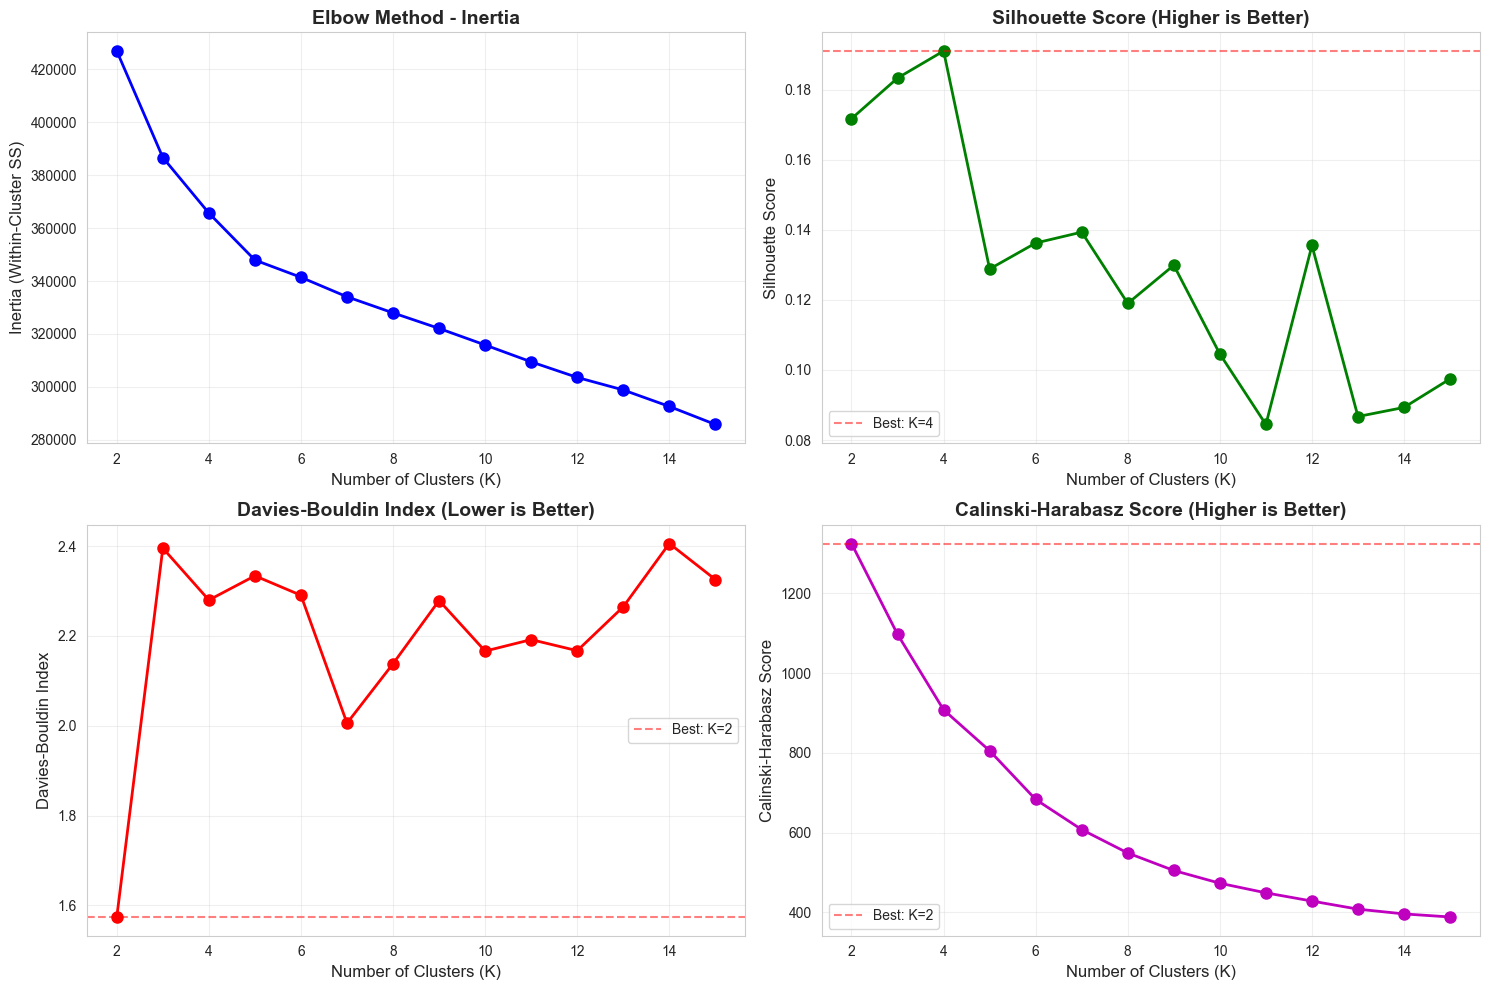


OPTIMAL K BY METRIC:
Best K by Silhouette Score: 4 (Score: 0.1911)
Best K by Davies-Bouldin: 2 (Score: 1.5741)
Best K by Calinski-Harabasz: 2 (Score: 1324.63)


In [5]:
# Visualize metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Elbow curve (Inertia)
axes[0, 0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0, 0].set_ylabel('Inertia (Within-Cluster SS)', fontsize=12)
axes[0, 0].set_title('Elbow Method - Inertia', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Silhouette Score (higher is better)
axes[0, 1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0, 1].set_ylabel('Silhouette Score', fontsize=12)
axes[0, 1].set_title('Silhouette Score (Higher is Better)', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axhline(y=max(silhouette_scores), color='r', linestyle='--', alpha=0.5, label=f'Best: K={k_range[silhouette_scores.index(max(silhouette_scores))]}')
axes[0, 1].legend()

# Davies-Bouldin Index (lower is better)
axes[1, 0].plot(k_range, davies_bouldin_scores, 'ro-', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1, 0].set_ylabel('Davies-Bouldin Index', fontsize=12)
axes[1, 0].set_title('Davies-Bouldin Index (Lower is Better)', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axhline(y=min(davies_bouldin_scores), color='r', linestyle='--', alpha=0.5, label=f'Best: K={k_range[davies_bouldin_scores.index(min(davies_bouldin_scores))]}')
axes[1, 0].legend()

# Calinski-Harabasz Score (higher is better)
axes[1, 1].plot(k_range, calinski_harabasz_scores, 'mo-', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1, 1].set_ylabel('Calinski-Harabasz Score', fontsize=12)
axes[1, 1].set_title('Calinski-Harabasz Score (Higher is Better)', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axhline(y=max(calinski_harabasz_scores), color='r', linestyle='--', alpha=0.5, label=f'Best: K={k_range[calinski_harabasz_scores.index(max(calinski_harabasz_scores))]}')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Print best K for each metric
print("\n" + "="*60)
print("OPTIMAL K BY METRIC:")
print("="*60)
print(f"Best K by Silhouette Score: {k_range[silhouette_scores.index(max(silhouette_scores))]} (Score: {max(silhouette_scores):.4f})")
print(f"Best K by Davies-Bouldin: {k_range[davies_bouldin_scores.index(min(davies_bouldin_scores))]} (Score: {min(davies_bouldin_scores):.4f})")
print(f"Best K by Calinski-Harabasz: {k_range[calinski_harabasz_scores.index(max(calinski_harabasz_scores))]} (Score: {max(calinski_harabasz_scores):.2f})")
print("="*60)

## Perform Final K-Means Clustering

Based on the metrics above, we'll choose an optimal K value and perform the final clustering.

In [6]:
# Choose optimal K (using best silhouette score)
optimal_k = k_range[silhouette_scores.index(max(silhouette_scores))]
print(f"Using optimal K = {optimal_k} (based on Silhouette Score)")

# Perform final K-Means clustering
print(f"\nPerforming K-Means clustering with K={optimal_k}...")
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10, max_iter=300)
final_labels = final_kmeans.fit_predict(df)

# Calculate final metrics
final_silhouette = silhouette_score(df, final_labels)
final_davies_bouldin = davies_bouldin_score(df, final_labels)
final_calinski_harabasz = calinski_harabasz_score(df, final_labels)

print("\n" + "="*60)
print("FINAL CLUSTERING RESULTS:")
print("="*60)
print(f"Number of Clusters (K): {optimal_k}")
print(f"Silhouette Score: {final_silhouette:.4f}")
print(f"Davies-Bouldin Index: {final_davies_bouldin:.4f}")
print(f"Calinski-Harabasz Score: {final_calinski_harabasz:.2f}")
print(f"Inertia: {final_kmeans.inertia_:.2f}")
print("="*60)

# Cluster size distribution
unique, counts = np.unique(final_labels, return_counts=True)
print("\nCluster Size Distribution:")
for cluster_id, count in zip(unique, counts):
    percentage = (count / len(final_labels)) * 100
    print(f"  Cluster {cluster_id}: {count:,} samples ({percentage:.1f}%)")

Using optimal K = 4 (based on Silhouette Score)

Performing K-Means clustering with K=4...

FINAL CLUSTERING RESULTS:
Number of Clusters (K): 4
Silhouette Score: 0.1911
Davies-Bouldin Index: 2.2800
Calinski-Harabasz Score: 907.81
Inertia: 365631.47

Cluster Size Distribution:
  Cluster 0: 3,251 samples (46.2%)
  Cluster 1: 1,584 samples (22.5%)
  Cluster 2: 1,526 samples (21.7%)
  Cluster 3: 682 samples (9.7%)


## Visualize Clusters using PCA

We'll use PCA to reduce dimensions to 2D for visualization.

Applying PCA for 2D visualization...
Explained variance ratio: [0.16859599 0.10436399]
Total variance explained: 27.30%


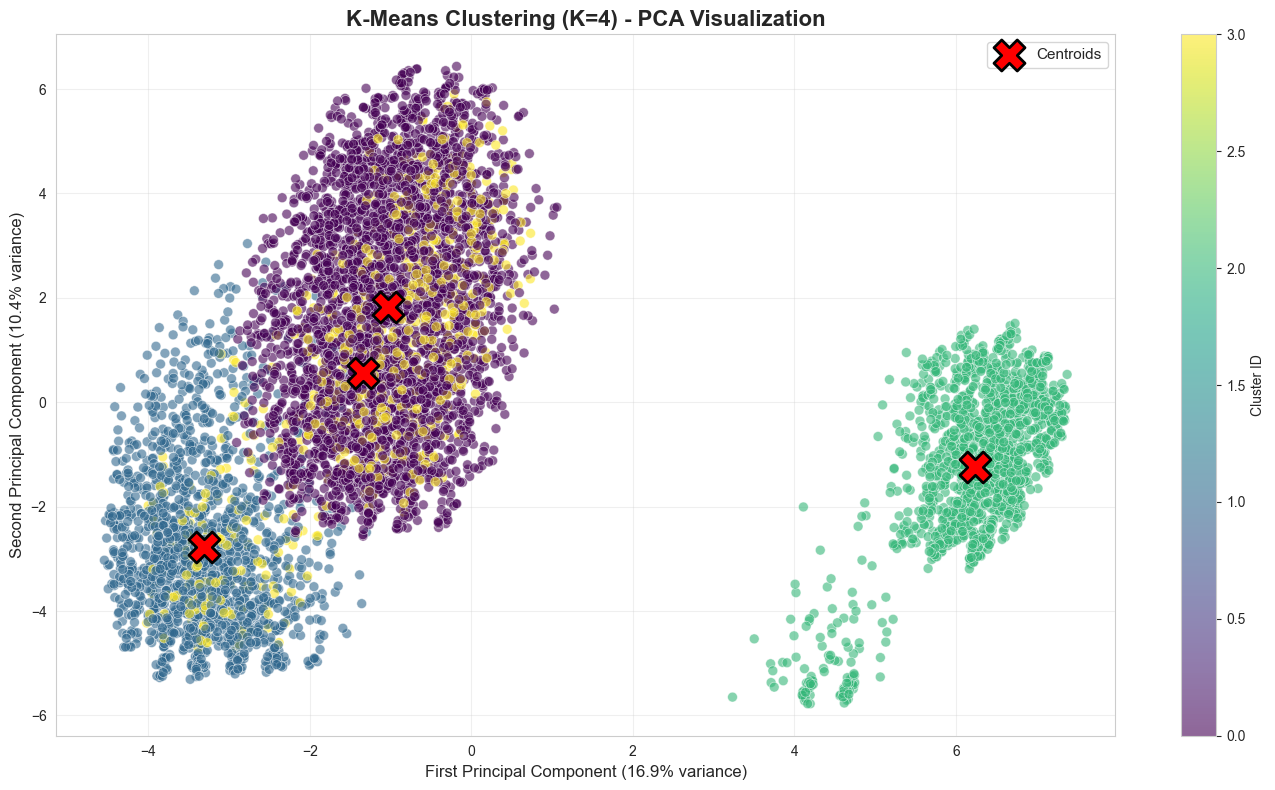

In [7]:
# Apply PCA for 2D visualization
print("Applying PCA for 2D visualization...")
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(df)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.2%}")

# Create visualization
plt.figure(figsize=(14, 8))

# Plot clusters
scatter = plt.scatter(
    pca_components[:, 0], 
    pca_components[:, 1], 
    c=final_labels, 
    cmap='viridis', 
    alpha=0.6,
    s=50,
    edgecolors='w',
    linewidth=0.5
)

# Plot cluster centers (transformed to PCA space)
centers_pca = pca.transform(final_kmeans.cluster_centers_)
plt.scatter(
    centers_pca[:, 0], 
    centers_pca[:, 1], 
    c='red', 
    marker='X', 
    s=500, 
    edgecolors='black',
    linewidth=2,
    label='Centroids',
    zorder=10
)

plt.xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
plt.title(f'K-Means Clustering (K={optimal_k}) - PCA Visualization', fontsize=16, fontweight='bold')
plt.colorbar(scatter, label='Cluster ID')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Save Clustering Results

In [8]:
# Save clustering results
output_file = r"C:\Users\weezh\OneDrive\Desktop\pyhercules\dataset\3rd exploration mdl implimentation\kmeans_clustering_results.csv"

# Create results DataFrame
results_df = df.copy()
results_df['Cluster'] = final_labels
results_df['PCA_1'] = pca_components[:, 0]
results_df['PCA_2'] = pca_components[:, 1]

# Save to CSV
results_df.to_csv(output_file, index=False)

print(f"✓ Clustering results saved to: {output_file}")
print(f"  - Total rows: {len(results_df):,}")
print(f"  - Total columns: {len(results_df.columns)} (including Cluster, PCA_1, PCA_2)")

# Summary statistics by cluster
print("\n" + "="*60)
print("SUMMARY BY CLUSTER:")
print("="*60)
for cluster_id in sorted(results_df['Cluster'].unique()):
    cluster_data = results_df[results_df['Cluster'] == cluster_id]
    print(f"\nCluster {cluster_id}:")
    print(f"  Size: {len(cluster_data):,} samples ({len(cluster_data)/len(results_df)*100:.1f}%)")
    print(f"  PCA_1 mean: {cluster_data['PCA_1'].mean():.4f}")
    print(f"  PCA_2 mean: {cluster_data['PCA_2'].mean():.4f}")

✓ Clustering results saved to: C:\Users\weezh\OneDrive\Desktop\pyhercules\dataset\3rd exploration mdl implimentation\kmeans_clustering_results.csv
  - Total rows: 7,043
  - Total columns: 75 (including Cluster, PCA_1, PCA_2)

SUMMARY BY CLUSTER:

Cluster 0:
  Size: 3,251 samples (46.2%)
  PCA_1 mean: -1.0359
  PCA_2 mean: 1.8144

Cluster 1:
  Size: 1,584 samples (22.5%)
  PCA_1 mean: -3.3073
  PCA_2 mean: -2.7738

Cluster 2:
  Size: 1,526 samples (21.7%)
  PCA_1 mean: 6.2371
  PCA_2 mean: -1.2341

Cluster 3:
  Size: 682 samples (9.7%)
  PCA_1 mean: -1.3364
  PCA_2 mean: 0.5549
